# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 11 </span>
## <span style="color:orange"> Keras - Neural Network regression </span>

### Overview 

In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).

We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

### Exercise 11.1

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.

Let's start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

In [4]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Now let's generate a set of input data which will slightly deviate from our ideal behaviour using a random noise (that actually is set to zero):

In [60]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 1000)
x_valid = np.random.uniform(-1, 1, 100)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.2 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

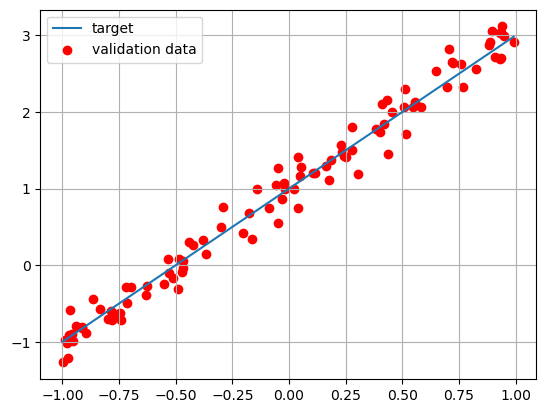

In [61]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

If you remember how a single node of a neural network works, you can easily spot that **just a single neuron can make the job**. So let's start using a simple Sequential model with just one layer on one neuron only!

In [63]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [64]:
# get a summary of our composed model
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [65]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2178 - mse: 4.2178 - val_loss: 3.5903 - val_mse: 3.5903
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5492 - mse: 2.5492 - val_loss: 2.2719 - val_mse: 2.2719
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6053 - mse: 1.6053 - val_loss: 1.4824 - val_mse: 1.4824
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0413 - mse: 1.0413 - val_loss: 0.9739 - val_mse: 0.9739
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6811 - mse: 0.6811 - val_loss: 0.6493 - val_mse: 0.6493
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4530 - mse: 0.4530 - val_loss: 0.4408 - val_mse: 0.4408
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3081 - mse: 0.3081 - val_loss: 0.3030 - val_mse: 0.3030
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2133 - mse: 0.2133 - val_loss: 0.2129 - val_mse: 0.2129
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1522 - mse: 

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [66]:
# return weights and biases
model.get_weights()

[array([[1.9949237]], dtype=float32), array([1.0033486], dtype=float32)]

In [67]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)
print('Validation loss:', score[0])
print()

# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)
print('Target loss:', score[0])


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0331 - mse: 0.0331 
Validation loss: 0.033064164221286774

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2537e-05 - mse: 2.2537e-05 
Target loss: 2.2536736651090905e-05


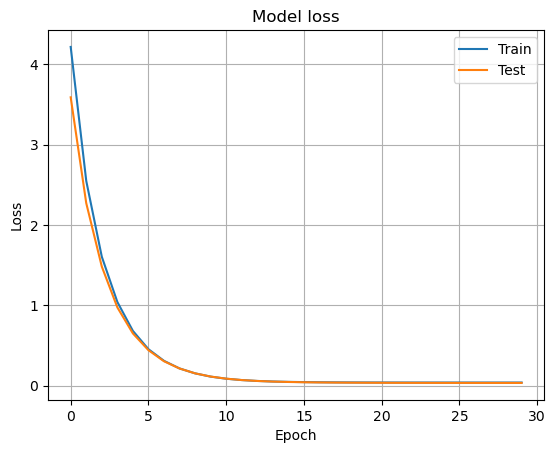

In [68]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


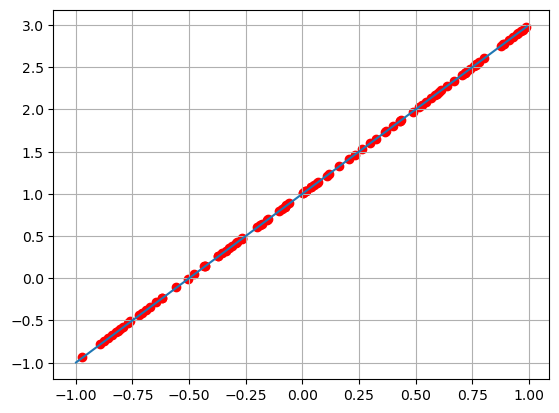

In [69]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

### Commenti
Il codice è stato testato usando diversi valori di:
-   $N_{train} = 500, 1000, 2000$;
-   $N_{epochs} = 15, 25, 35$;
-   $\sigma = 0.1, 0.2, 0.3, 0.5$.

Per la prima variabile, i valori di loss di (validation, target) sono passati da $(0.0489, 0.0049), (0.0329, 3 \cdot 10^{-6}), (0.0427, 3 \cdot 10^{-5})$ mostrando che il valore ottimale è quello di $N_{train} = 1000$. Con questo input è stato fatto variare il numero di epoche ottenendo loss pari a $(0.0334, 7 \cdot 10^{-5}), (0.0329, 9 \cdot 10^{-6}), (0.0329, 1 \cdot 10^{-6})$ che indicano un andamento asintotico dopo circa 20 epoche. Con 30 epoche, sono stati fatti gli ultimi test variando sigma, i quali hanno mostrato loss pari a $(0.0082, 8 \cdot 10^{-6}), (0.0334, 2 \cdot 10^{-5}), (0.0745, 5 \cdot 10^{-5}), (0.2057, 8 \cdot 10^{-5})$, ovvero un andamento crescente.


### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

In [8]:
x_train = np.random.uniform(-1, 1, 10000)
x_valid = np.random.uniform(-1, 1, 1000)
x_valid.sort()
y_target = 4 - 3*x_valid - 2*x_valid*x_valid + 3*x_valid*x_valid*x_valid # ideal (target) linear function

sigma = 0.2     #noise standard deviation
y_train = np.random.normal(4 - 3*x_train - 2*x_train*x_train + 3*x_train*x_train*x_train, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(4 - 3*x_valid - 2*x_valid*x_valid + 3*x_valid*x_valid*x_valid, sigma)

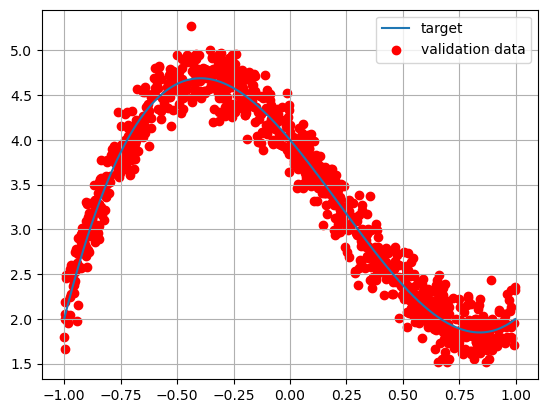

In [9]:
# plot validation and target dataset
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# compose the NN model
model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(8, activation='tanh'))
model.add(Dense(4, activation='tanh'))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

In [29]:
# get a summary of our composed model
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [30]:
# fit the model using training dataset
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=50,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.3724 - mse: 6.3724 - val_loss: 1.6003 - val_mse: 1.6003
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8319 - mse: 0.8319 - val_loss: 0.4565 - val_mse: 0.4565
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4252 - mse: 0.4252 - val_loss: 0.3840 - val_mse: 0.3840
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3880 - mse: 0.3880 - val_loss: 0.3630 - val_mse: 0.3630
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3641 - mse: 0.3641 - val_loss: 0.3359 - val_mse: 0.3359
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2989 - mse: 0.2989 - val_loss: 0.2002 - val_mse: 0.2002
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1414 - mse: 0.1414 - val_loss: 0.0801 - val_mse: 0.0801
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0639 - mse: 0.0639 - val_loss: 0.0461 - val_mse: 0.0461
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [31]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)
print('Validation loss:', score[0])
print()

# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)
print('Target loss:', score[0])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0402 - mse: 0.0402 
Validation loss: 0.04021431878209114

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - mse: 0.0016 
Target loss: 0.0015973804984241724


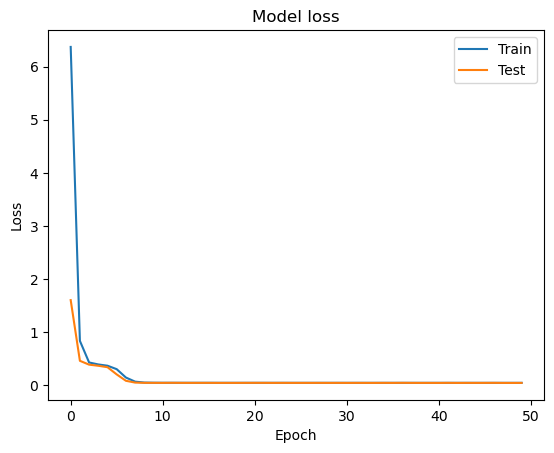

In [35]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


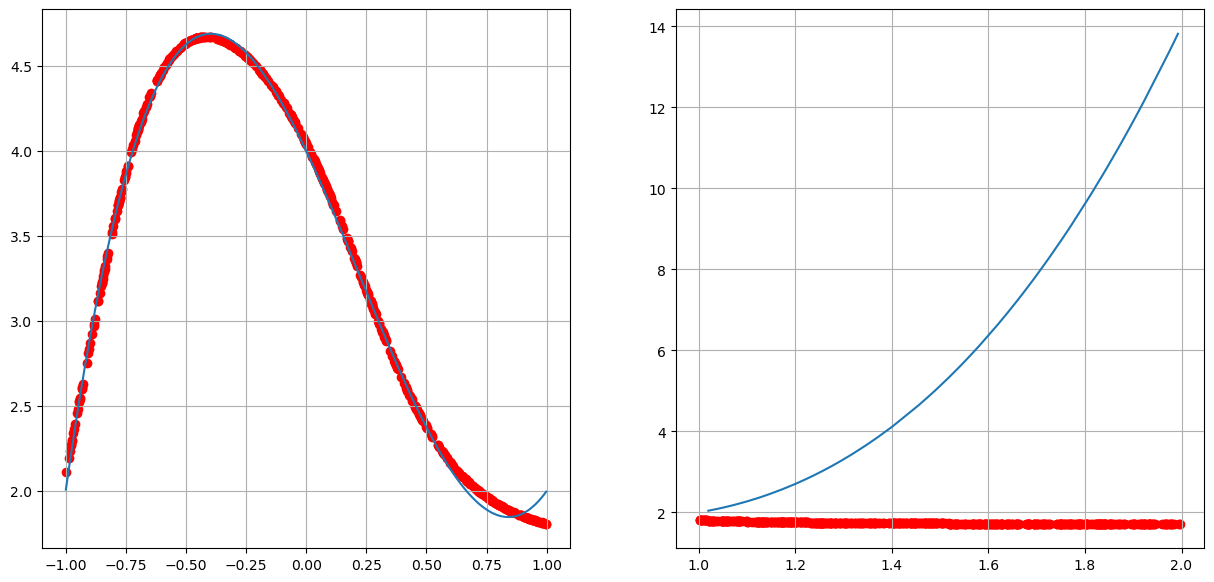

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 31.4854 - mse: 31.4854
Test loss outside: 31.485383987426758


In [39]:
fig, ax = plt.subplots(1, 2, figsize=(15,7))

x_predicted = np.random.uniform(-1, 1, 500)
y_predicted = model.predict(x_predicted)
ax[0].scatter(x_predicted, y_predicted, color='r')
ax[0].plot(x_valid, y_target)
ax[0].grid(True)

x_pred_out = np.random.uniform(1, 2, 500)
y_pred_out = model.predict(x_pred_out)
x_val_out = np.random.uniform(1, 2, 100)
x_val_out.sort()
y_targ_out = 4 - 3*x_val_out - 2*x_val_out*x_val_out + 3*x_val_out*x_val_out*x_val_out
ax[1].scatter(x_pred_out, y_pred_out, color='r')
ax[1].plot(x_val_out, y_targ_out)
ax[1].grid(True)
plt.show()
score_out = model.evaluate(x_val_out, y_targ_out, batch_size=32, verbose=1)
print('Test loss outside:', score_out[0])

### Commenti
Sono stati utilizzati due layer da 8 e 4 neuroni in quanto, partendo da un numero di neuroni maggiore, si è cercato di ridurre i parametri senza perdere precisione in modo significativo. La funzione di attivazione è la tanh, sperimentalmente preferita alla relu che mostrava un plot delle y_predicted composto da spezzate piuttosto che da una forma ondulata. Come ottimizzatore ho utilizzato adam che ho notato essere più preciso del sgd. Infine, come loss function ho preferito il mse invece che il mae per lo stesso motivo.\
Il risultato mostra un nuon accordo tra i punti predetti e quelli teorici all'interno del range di train (con una target loss di 0.0016), eccetto che per la piccola risalita in prossimità di 1. All'esterno del range, tra [1, 2] l'algoritmo non riesce a predire correttamente l'andamento della cuerva come si può notare dal grafico e dal valore di loss (pari a 27).


### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

Ideas to meditate on these exercises and judge your results can be found <a href=https://xkcd.com/2048/>here</a>

In [40]:
x_train = np.random.uniform(-1.5, 1.5, size=(5000, 2))
x_valid = np.random.uniform(-1.5, 1.5, size=(500, 2))

sigma = 0.2 # noise standard deviation
y_train = np.random.normal(np.sin(x_train[:,0]**2 + x_train[:,1]**2), sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(np.sin(x_valid[:,0]**2 + x_valid[:,1]**2), sigma) 

In [41]:
model = tf.keras.Sequential()
model.add(Input(shape=(2,)))    # sono due i dati di input
model.add(Dense(64, activation='tanh'))
model.add(Dense(32, activation='tanh'))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

In [42]:
history = model.fit(x=x_train, y=y_train, 
          batch_size=40, epochs=60,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2309 - mse: 0.2309 - val_loss: 0.1784 - val_mse: 0.1784
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1918 - mse: 0.1918 - val_loss: 0.1795 - val_mse: 0.1795
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1930 - mse: 0.1930 - val_loss: 0.1777 - val_mse: 0.1777
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1944 - mse: 0.1944 - val_loss: 0.1857 - val_mse: 0.1857
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1921 - mse: 0.1921 - val_loss: 0.1797 - val_mse: 0.1797
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1913 - mse: 0.1913 - val_loss: 0.1826 - val_mse: 0.1826
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1908 - mse: 0.1908 - val_loss: 0.1831 - val_mse: 0.1831
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1910 - mse: 0.1910 - val_loss: 0.1966 - val_mse: 0.1966
Epoch 9/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 30s 955us/step


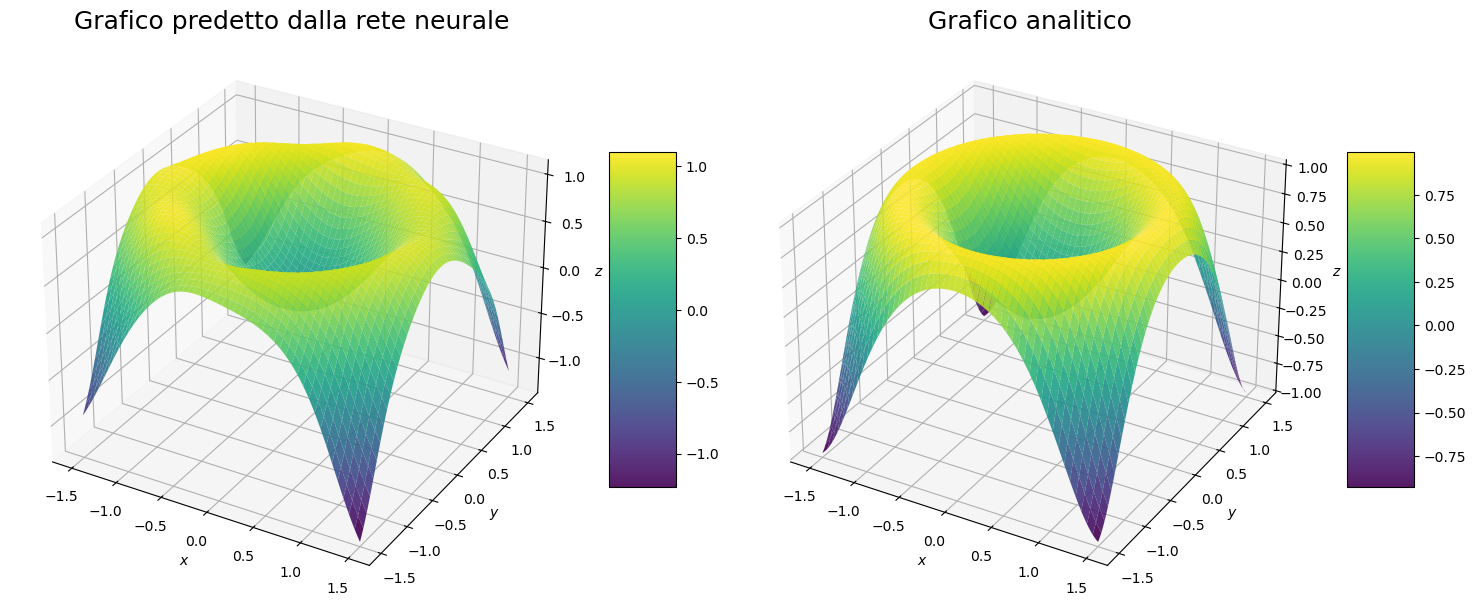

In [58]:
x_predicted = np.linspace(-1.5, 1.5, 1000)
x1_grid, x2_grid = np.meshgrid(x_predicted, x_predicted)    # genera due griglie 1000x1000 con tutti i valori della coordinata x (o y) 
x_cols = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))   # trasforma le due griglie in un vettore di due colonne
#ciascuna colonna contiene tutti i valori di una griglia, quindi tutte le coordinate x (o y) di tutti i punti

y_predicted = model.predict(x_cols)
y_pred = y_predicted.reshape(x1_grid.shape)  # rigenera una griglia necessaria per la rappresentazione con matplotlib

fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(121, projection="3d") # dividi la figura in due grafici di 1 riga e 2 colonne e seleziona il numero 1 (121)

surf_pred = ax.plot_surface(x1_grid, x2_grid, y_pred, cmap="viridis", alpha=0.9)
ax.set_title("Grafico predetto dalla rete neurale", fontsize=18)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
fig.colorbar(surf_pred, shrink=0.5, aspect=5)

y_target = np.sin(x_cols[:,0]**2 + x_cols[:,1]**2)
y_targ = y_target.reshape(x1_grid.shape)

ax = fig.add_subplot(122, projection="3d") # seleziona il grafico 2 (122)

surf_teo = ax.plot_surface(x1_grid, x2_grid, y_targ, cmap="viridis", alpha=0.9)
ax.set_title("Grafico analitico", fontsize=18)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
fig.colorbar(surf_teo, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()


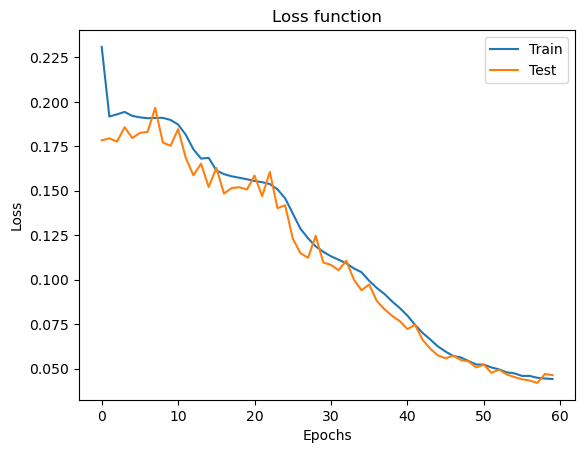

15625/15625 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0073 - mse: 0.0073
Target loss: 0.007291276007890701


In [59]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss function')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Test'], loc='best')
plt.show()
score = model.evaluate(x_cols, y_target, batch_size=64, verbose=1)
print('Target loss:', score[0])

### Commenti
La rete neurale riesce ad approssimare bene la funzione teorica come si può notare dal confronto dei due grafici e dall'andamento decrescente della loss, che dopo 60 epoche raggiunge il valore di 0.007.